# ⚙️ Feature Engineering for Modeling — Blu App Review

Notebook ini **berbeda** dari `5-TFIDF-BluAppReview.ipynb`.

| | 5-TFIDF (eksplorasi) | **5b ini (for modeling)** |
|---|---|---|
| Tujuan | Memahami data, visualisasi | Produce fitur untuk training model |
| Fit vectorizer pada | Seluruh data | Training set saja (anti data leakage) |
| Output | Word cloud, histogram, summary | CSV bersih + vectorizer.pkl |

**Output notebook ini:**
- `../data/blu_modeling_ready.csv` → teks + label, siap masuk modeling
- `../data/tfidf_vectorizer.pkl` → vectorizer yang sudah di-fit pada train set
- `../data/train_test_split_info.pkl` → indeks train/test untuk reprodusibilitas

## 1. Import Library

In [12]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

os.makedirs('../data', exist_ok=True)
os.makedirs('../data/visualisasi', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
print('✅ Library siap!')

✅ Library siap!


## 2. Load Data

> **Catatan:** Jika sudah menjalankan `hybrid_labeling.ipynb`, ganti ke `blu_hybrid_labeled.csv`.

In [13]:
# ── Ganti ke 'blu_hybrid_labeled.csv' jika sudah jalankan hybrid labeling
INPUT_FILE = '../data/bluapp_reviews_labeled_binary.csv'

TEXT_COL  = 'final_content'  # kolom teks bersih hasil preprocessing
LABEL_COL = 'sentiment'      # kolom label sentimen

df = pd.read_csv(INPUT_FILE)
print(f'Data dimuat: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
df.head(3)

Data dimuat: (24533, 16)
Kolom: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'final_content', 'tokens_stemmed', 'sentiment', 'label_method', 'label_reason', 'word_count', 'pos_count', 'neg_count', 'net_score', 'text_label', 'rating_label']


,content,score,at,thumbsUpCount,replyContent,final_content,tokens_stemmed,sentiment,label_method,label_reason,word_count,pos_count,neg_count,net_score,text_label,rating_label
0,"verifikasi wajah tidak jelas,stuck di pastikan...",1,2026-05-16 23:08:41,0,"Hai, Kak Darma. Maaf atas ketidaknyamanannya. ...",verifikasi wajah jelastuck pasti hp gerak hp t...,"['verifikasi', 'wajah', 'jelastuck', 'pasti', ...",negatif,rating,rating_ekstrem_rendah,10,0,0,0,netral,negatif
1,hihihihi kog ngeri nian baca review penggunany...,1,2026-05-16 22:10:32,0,"Hai, Kak Maulana. Maaf atas ketidaknyamanannya...",hihihihi kog ngeri nian baca review guna horor...,"['hihihihi', 'kog', 'ngeri', 'nian', 'baca', '...",negatif,rating,rating_ekstrem_rendah,14,0,0,0,netral,negatif
2,gak perlu di instal hanya menghabiskan paket d...,1,2026-05-16 21:52:46,0,"Hai, Kak Jaki. Maaf atas ketidaknyamanannya. K...",instal habis paket data cuk,"['instal', 'habis', 'paket', 'data', 'cuk']",negatif,rating,rating_ekstrem_rendah,5,0,0,0,netral,negatif


In [14]:
# Validasi kolom
assert TEXT_COL in df.columns,  f'Kolom teks "{TEXT_COL}" tidak ditemukan!'
assert LABEL_COL in df.columns, f'Kolom label "{LABEL_COL}" tidak ditemukan!'

# Bersihkan baris kosong
before = len(df)
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != '']
print(f'Baris dihapus (kosong): {before - len(df)}')
print(f'Data siap: {len(df):,} baris')
print()
print('Distribusi label:')
print(df[LABEL_COL].value_counts())

Baris dihapus (kosong): 0
Data siap: 24,533 baris

Distribusi label:
sentiment
positif    16857
negatif     7676
Name: count, dtype: int64


## 3. Train-Test Split

Split dilakukan **di sini**, sebelum vectorizer di-fit.
Ini penting supaya vectorizer hanya belajar dari training data → tidak ada data leakage.

In [15]:
X = df[TEXT_COL]
y = df[LABEL_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Pastikan ini menggunakan .index.tolist() dari hasil split langsung
print('X_train index sample:', X_train.index.tolist()[:5])
print('X_test  index sample:', X_test.index.tolist()[:5])
print('X_train index max:', X_train.index.max())
print('X_test  index max:', X_test.index.max())

X_train index sample: [775, 4167, 7756, 4850, 4407]
X_test  index sample: [19666, 2927, 7375, 11994, 15763]
X_train index max: 24532
X_test  index max: 24530


## 4. TF-IDF Vectorizer — Fit pada Train, Transform Train & Test

```
vectorizer.fit_transform(X_train)  ← belajar vocab dari train saja
vectorizer.transform(X_test)       ← test hanya ditransform, tidak ikut belajar
```

Parameter dipilih untuk klasifikasi sentimen (bukan eksplorasi):
- `max_features=15000` → batasi vocab supaya tidak overfitting
- `ngram_range=(1,2)` → unigram + bigram, tangkap frasa seperti "tidak bisa"
- `sublinear_tf=True` → log-scale frekuensi, kata yang muncul 10x ≠ 10x lebih penting
- `min_df=3` → buang kata yang muncul < 3 dokumen (noise)
- `max_df=0.95` → buang kata yang muncul di > 95% dokumen (terlalu umum)

In [16]:
vectorizer = TfidfVectorizer(
    max_features  = 15000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 3,
    max_df        = 0.95,
)

# Fit HANYA pada train, lalu transform keduanya
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

feature_names = vectorizer.get_feature_names_out()

print(f'Vocabulary size : {len(feature_names):,} fitur')
print(f'Train matrix    : {X_train_tfidf.shape}  (sparse)')
print(f'Test matrix     : {X_test_tfidf.shape}   (sparse)')
print(f'Density train   : {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])*100:.3f}% non-zero')

Vocabulary size : 7,928 fitur
Train matrix    : (19626, 7928)  (sparse)
Test matrix     : (4907, 7928)   (sparse)
Density train   : 0.095% non-zero


## 5. Eksplorasi Singkat Fitur (Opsional, tidak masuk modeling)

Bagian ini hanya untuk memahami fitur yang dihasilkan. Tidak ada data leakage di sini karena hanya menggunakan training set.

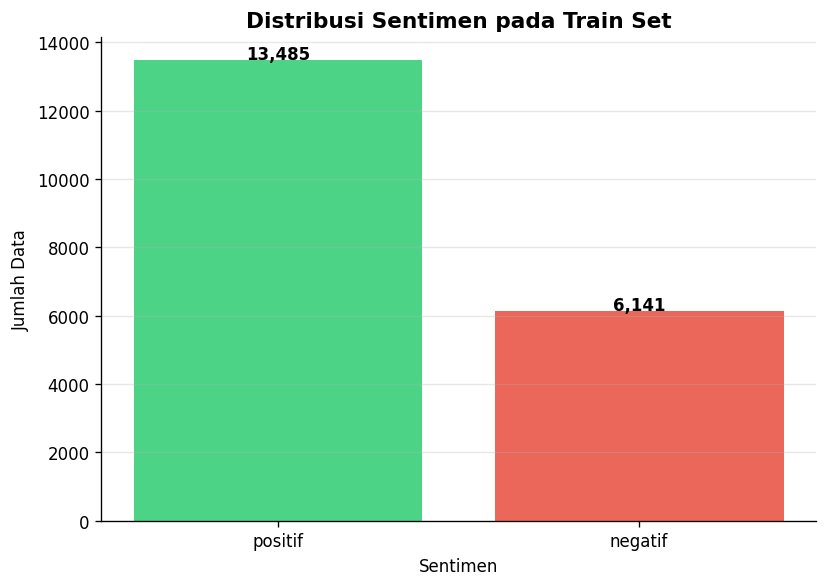

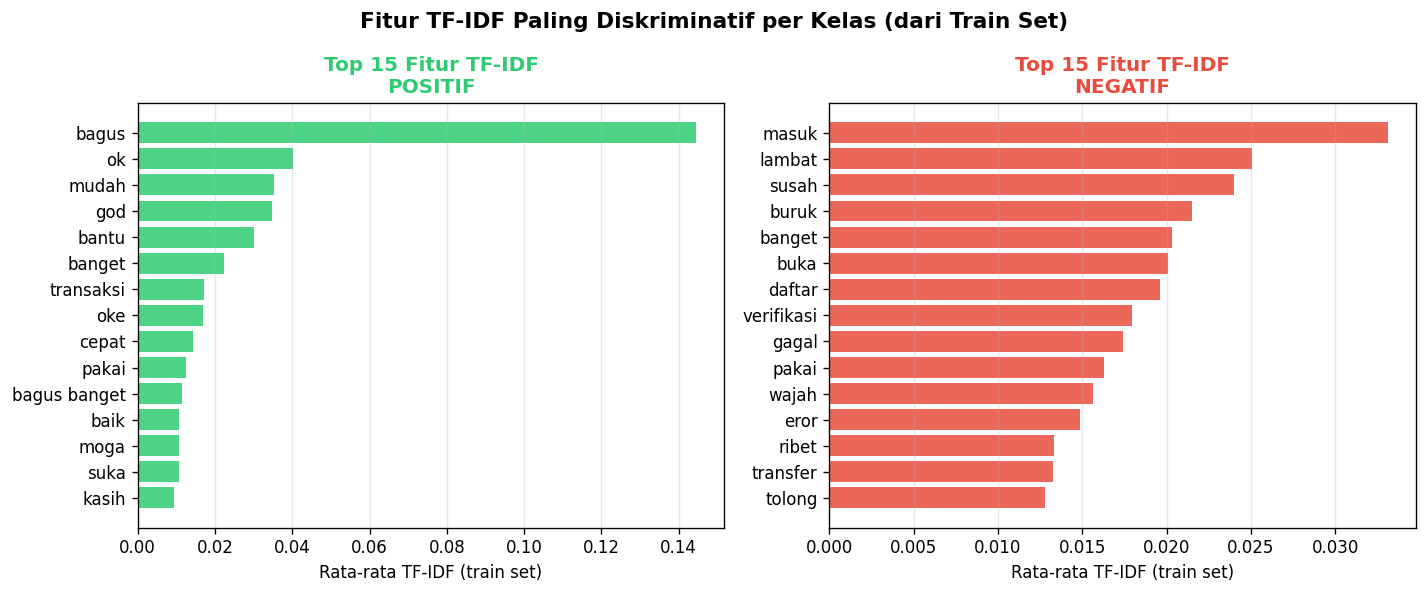

✅ Visualisasi disimpan.


In [17]:
# Top kata per kelas sentimen berdasarkan rata-rata TF-IDF di training set
train_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=feature_names
)
train_df['sentiment'] = y_train.values

COLORS = {'positif': '#2ECC71', 'negatif': '#E74C3C', 'netral': '#F39C12'}
labels = [l for l in ['positif', 'negatif', 'netral'] if l in train_df['sentiment'].unique()]

# =========================================================
# Distribusi Sentimen pada Train Set
# =========================================================

sentiment_counts = train_df['sentiment'].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[COLORS.get(lbl, '#3498DB') for lbl in sentiment_counts.index],
    alpha=0.85
)

# Label jumlah data
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 20,
        f'{int(h):,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Distribusi Sentimen pada Train Set',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')

plt.grid(axis='y', alpha=0.3)

# Hilangkan border atas & kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    '../data/visualisasi/sentiment_distribution_trainset.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

fig, axes = plt.subplots(1, len(labels), figsize=(6*len(labels), 5))
if len(labels) == 1: axes = [axes]

for ax, label in zip(axes, labels):
    subset = train_df[train_df['sentiment'] == label].drop(columns='sentiment')
    top15  = subset.mean().sort_values(ascending=False).head(15)

    ax.barh(top15.index[::-1], top15.values[::-1],
            color=COLORS.get(label, '#3498DB'), alpha=0.85)
    ax.set_title(f'Top 15 Fitur TF-IDF\n{label.upper()}',
                 fontweight='bold', color=COLORS.get(label, 'black'))
    ax.set_xlabel('Rata-rata TF-IDF (train set)')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Fitur TF-IDF Paling Diskriminatif per Kelas (dari Train Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/visualisasi/top_tfidf_features_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Hapus train_df besar dari memori
del train_df
print('✅ Visualisasi disimpan.')

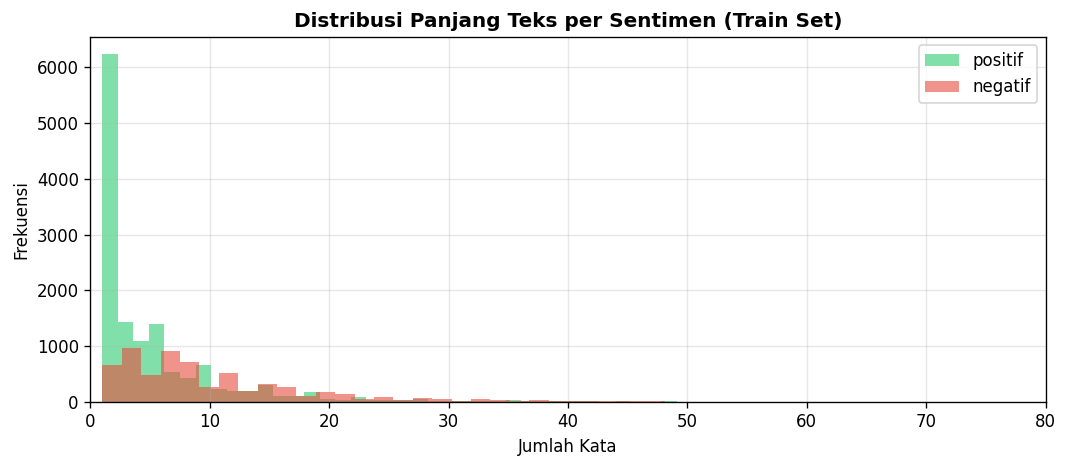

In [18]:
# Distribusi panjang teks per kelas
temp = X_train.to_frame()
temp['sentiment'] = y_train.values
temp['word_count'] = temp[TEXT_COL].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
for label in labels:
    subset = temp[temp['sentiment'] == label]['word_count']
    ax.hist(subset, bins=40, alpha=0.6,
            color=COLORS.get(label, '#3498DB'), label=label)
ax.set_title('Distribusi Panjang Teks per Sentimen (Train Set)', fontweight='bold')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.set_xlim(0, 80)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/visualisasi/distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

del temp

## 6. Simpan Output untuk Modeling

In [19]:
# ── (A) Simpan CSV bersih: teks + label saja
# Modeling notebook akan load ini dan lakukan TF-IDF via Pipeline-nya sendiri
# (Pipeline di modeling di-fit pada train split-nya → tetap aman dari leakage)

df_out = df[[TEXT_COL, LABEL_COL]].copy()
df_out.to_csv('../data/blu_modeling_ready.csv', index=False)
print(f'✅ (A) CSV modeling disimpan: ../data/blu_modeling_ready.csv')
print(f'   Shape: {df_out.shape} | Kolom: {df_out.columns.tolist()}')

✅ (A) CSV modeling disimpan: ../data/blu_modeling_ready.csv
   Shape: (24533, 2) | Kolom: ['final_content', 'sentiment']


In [20]:
# ── (B) Simpan vectorizer yang sudah di-fit pada train set
# Berguna jika ingin deploy model atau inference tanpa re-fit

with open('../data/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print(f'✅ (B) Vectorizer disimpan: ../data/tfidf_vectorizer.pkl')
print(f'   Vocab size: {len(feature_names):,} fitur')

✅ (B) Vectorizer disimpan: ../data/tfidf_vectorizer.pkl
   Vocab size: 7,928 fitur


In [21]:
# ── (C) Simpan indeks train/test untuk reprodusibilitas
# Supaya modeling notebook bisa pakai split yang sama persis

split_info = {
    'train_index' : list(range(len(X_train))),
    'test_index'  : X_test.index.tolist(),
    'random_state': 42,
    'test_size'   : 0.2,
    'text_col'    : TEXT_COL,
    'label_col'   : LABEL_COL,
    'n_train'     : len(X_train),
    'n_test'      : len(X_test),
}

with open('../data/train_test_split_info.pkl', 'wb') as f:
    pickle.dump(split_info, f)
print(f'✅ (C) Split info disimpan: ../data/train_test_split_info.pkl')

✅ (C) Split info disimpan: ../data/train_test_split_info.pkl


In [22]:
# Ringkasan akhir
print('='*55)
print('  RINGKASAN OUTPUT')
print('='*55)
print(f'  blu_modeling_ready.csv      → input Modeling')
print(f'  tfidf_vectorizer.pkl        → vectorizer (deploy/inference)')
print(f'  train_test_split_info.pkl   → indeks split')
print(f'  visualisasi/*.png           → grafik fitur')
print('='*55)
print()
print('Langkah berikutnya:')
print('  → Buka 6-modeling.ipynb')
print('  → Ganti INPUT_FILE ke: ../data/blu_modeling_ready.csv')
print('  → TEXT_COL = "final_content", LABEL_COL = "sentiment"')

  RINGKASAN OUTPUT
  blu_modeling_ready.csv      → input Modeling
  tfidf_vectorizer.pkl        → vectorizer (deploy/inference)
  train_test_split_info.pkl   → indeks split
  visualisasi/*.png           → grafik fitur

Langkah berikutnya:
  → Buka 6-modeling.ipynb
  → Ganti INPUT_FILE ke: ../data/blu_modeling_ready.csv
  → TEXT_COL = "final_content", LABEL_COL = "sentiment"
